## Wash count drivers — yearly site analysis (full-site-wise_with_yearly_agg)

**Sections:**
1. **Snapshot** — n, target ranges, multi/single split, variance decomposition + USA map (region halo + localisation dots).
2. **Correlation matrices — global · region · localisation** — same top features, three side-by-side heatmaps at three geographic scopes. Bootstrap CIs on the global view flag noise.
3. **SHAP feature importance** — multivariate, non-linear, model-aware view per target.

In [1]:
pip install folium


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestRegressor
import shap

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
from pathlib import Path

csv_candidates = [
    Path('../hypothesis-testing/_no_chem_data/full-site-wise_with_yearly_agg.csv'),
    Path('hypothesis-testing/_no_chem_data/full-site-wise_with_yearly_agg.csv'),
]
csv_path = next((p for p in csv_candidates if p.exists()), csv_candidates[0])
df = pd.read_csv(csv_path)

# --- Schema harmonization (yearly file uses different names than sitewise-report.csv) ---
col_aliases = {
    '2024_wash_count_retail': '2024_retail',
    '2025_wash_count_retail': '2025_retail',
    '2024_wash_count_membership': '2024_membership',
    '2025_wash_count_membership': '2025_membership',
}
for target_col, source_col in col_aliases.items():
    if target_col not in df.columns and source_col in df.columns:
        df[target_col] = df[source_col]

if 'region' not in df.columns:
    df['region'] = 'all'
if 'site_type' not in df.columns:
    df['site_type'] = 'unknown'
if 'localisation' not in df.columns:
    df['localisation'] = 1

if 'Address' not in df.columns and 'Name' in df.columns:
    df['Address'] = df['Name']
if 'state' not in df.columns:
    df['state'] = 'NA'
if 'city' not in df.columns:
    df['city'] = 'NA'
if 'zip' not in df.columns:
    df['zip'] = 'NA'

if 'latitude' not in df.columns and 'Latitude' in df.columns:
    df['latitude'] = df['Latitude']
if 'longitude' not in df.columns and 'Longitude' in df.columns:
    df['longitude'] = df['Longitude']

# Targets (summed yearly totals)
if 'target_retail' not in df.columns:
    df['target_retail'] = df['2024_retail'].fillna(0) + df['2025_retail'].fillna(0)
if 'target_membership' not in df.columns:
    df['target_membership'] = df['2024_membership'].fillna(0) + df['2025_membership'].fillna(0)
if 'target_wash_total' not in df.columns:
    df['target_wash_total'] = df['target_retail'] + df['target_membership']

targets = pd.DataFrame({
    'retail': df['target_retail'],
    'membership': df['target_membership'],
    'wash_total': df['target_wash_total']
})

# Feature engineering
def coerce(s):
    if pd.isna(s): return np.nan
    if isinstance(s, (int, float, np.integer, np.floating)): return float(s)
    c = re.sub(r'[\$,%\s]', '', str(s))
    if c in ('', '-', 'nan', 'NaN'): return np.nan
    try:    return float(c)
    except: return np.nan

TARGETS = ['target_retail','target_membership','target_wash_total']
LEAK_TARGET_PARTS = [
    '2024_retail','2025_retail','2024_membership','2025_membership',
    '2024_total','2025_total',
    '2024_wash_count_retail','2025_wash_count_retail',
    '2024_wash_count_membership','2025_wash_count_membership'
]

# Geographic-identity columns. These describe WHERE the site is, not its 3-mile environment.
# They get excluded from X — but localisation + region are kept as grouping variables for analysis.
GEO_IDENTITY = ['latitude','longitude','Latitude','Longitude','region','state','city','zip',
                'dbscan_cluster_12km','dbscan_cluster_18km']
# Site-identity / maturity columns: the site's OWN age & open date, not its 3-mile environment.
SITE_MATURITY = ['age_on_30_sep_25', 'operational_start_date']
ID_COLS  = ['client_id_location_id','Address','client_id','Unnamed: 5','client_type']
DUP_COLS = ['Median Household Income.1','Average Household Income.1']
TEXT_COLS = [c for c in df.columns if any(k in c for k in ['-Name','-Website','-Chain Name'])]
CATEG = [c for c in df.columns if 'Competitor Type' in c or 'Car Wash Type' in c]

# Grouping variables kept separately for per-region / per-cluster analysis
loc_col    = df['localisation'].copy()
region_col = df['region'].copy()

work = df.drop(columns=[c for c in (GEO_IDENTITY + SITE_MATURITY + ID_COLS + DUP_COLS + TEXT_COLS)
                        if c in df.columns]).copy()

for c in work.columns:
    if c in CATEG or c in TARGETS or c in LEAK_TARGET_PARTS or c == 'localisation' or c == 'site_type': continue
    work[c] = work[c].apply(coerce)

# One-hot encode competitor types + site_type (site_type is operational, not geographic identity)
work = pd.get_dummies(work, columns=[c for c in CATEG + ['site_type'] if c in work.columns],
                      dummy_na=False)

X = (work.drop(columns=[c for c in (TARGETS + LEAK_TARGET_PARTS + ['localisation']) if c in work.columns])
         .fillna(work.median(numeric_only=True))
         .dropna(axis=1, how='any')
         .select_dtypes(include=[np.number, bool])
         .astype(float))

# Filter rare binary dummies: must fire in 5%-95% of sites to give a meaningful correlation
binary_cols = [c for c in X.columns if X[c].nunique() <= 2]
keep_binary = [c for c in binary_cols
               if 0.05 * len(X) <= X[c].sum() <= 0.95 * len(X)]
non_binary  = [c for c in X.columns if c not in binary_cols]
X = X[non_binary + keep_binary]

print(f'Sites: {len(df)}')
print(f'Localisation clusters: {loc_col.nunique()}  (sizes: '
      f'{sorted(loc_col.value_counts().tolist(), reverse=True)})')
print(f'Regions: {region_col.value_counts().to_dict()}')
print(f'Site type: {df.site_type.value_counts().to_dict()}')
print()
print(f'Feature matrix X: {X.shape[0]} sites × {X.shape[1]} substantive features')
print(f'  continuous     : {len(non_binary)}')
print(f'  binary (kept)  : {len(keep_binary)}   (filtered out {len(binary_cols)-len(keep_binary)} rare dummies)')
print('  excluded entirely: lat, lon, region, state, city, zip, dbscan IDs, site age, open date')
print()
print('Target summary:')
print(targets.describe().round(0).T[['mean','50%','min','max']])


Sites: 698
Localisation clusters: 102  (sizes: [35, 28, 25, 23, 22, 21, 21, 15, 13, 13, 12, 12, 11, 11, 11, 11, 11, 10, 10, 10, 9, 9, 8, 8, 8, 8, 8, 8, 8, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
Regions: {'South': 450, 'West': 108, 'Midwest': 77, 'Northeast': 63}
Site type: {'unknown': 698}

Feature matrix X: 698 sites × 47 substantive features
  continuous     : 38
  binary (kept)  : 9   (filtered out 269 rare dummies)
  excluded entirely: lat, lon, region, state, city, zip, dbscan IDs, site age, open date

Target summary:
                mean       50%   min       max
retail      143730.0  106802.0   0.0  845654.0
membership   65682.0   38580.0  15.0  629249.0
wash_total  209413.0  175598.0  87.0  870975.0


/Users/dhruvsood/sonnysDataCollection/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Snapshot

Numeric summary only — what we're working with before we look at drivers.

In [3]:
colors = {'retail':'#1f77b4', 'membership':'#ff7f0e', 'wash_total':'#2ca02c'}

def var_explained(group):
    g_means = targets['wash_total'].groupby(group).mean()
    grand_mean = targets['wash_total'].mean()
    between = ((g_means - grand_mean) ** 2 * group.value_counts()).sum()
    total = ((targets['wash_total'] - grand_mean) ** 2).sum()
    return between / total

print('=== Targets (per site) ===')
print(targets.describe().round(0).T[['mean','50%','min','max']].to_string())

# Prefer client_type counts (true source in this CSV); fallback to site_type if needed
if 'client_type' in df.columns and df['client_type'].notna().any():
    n_multi  = (df['client_type'].astype(str).str.lower() == 'multi_site').sum()
    n_single = (df['client_type'].astype(str).str.lower() == 'single_site').sum()
else:
    n_multi  = (df['site_type'].astype(str).str.lower() == 'multi_site').sum()
    n_single = (df['site_type'].astype(str).str.lower() == 'single_site').sum()
region_counts = region_col.value_counts().to_dict()
cluster_size_dist = dict(loc_col.value_counts().value_counts().sort_index())

print('\n=== Sample composition ===')
print(f'  n sites                        : {len(df)}')
print(f'  multi_site / single_site       : {n_multi} / {n_single}')
print(f'  regions (n)                    : {region_counts}')
print(f'  localisation clusters          : {loc_col.nunique()} (size buckets: {cluster_size_dist})')

print('\n=== Variance decomposition of wash_total ===')
print(f'  share at region level          : {var_explained(region_col):>5.1%}')
print(f'  share at state level           : {var_explained(df["state"]):>5.1%}')
print(f'  share at localisation level    : {var_explained(loc_col):>5.1%}')
print('  => most of the wash_total signal is at the cluster level.')
print('     Site-level features can only explain the remaining ~42%.')

=== Targets (per site) ===
                mean       50%   min       max
retail      143730.0  106802.0   0.0  845654.0
membership   65682.0   38580.0  15.0  629249.0
wash_total  209413.0  175598.0  87.0  870975.0

=== Sample composition ===
  n sites                        : 698
  multi_site / single_site       : 394 / 304
  regions (n)                    : {'South': 450, 'West': 108, 'Midwest': 77, 'Northeast': 63}
  localisation clusters          : 102 (size buckets: {2: np.int64(10), 3: np.int64(18), 4: np.int64(19), 5: np.int64(14), 6: np.int64(5), 7: np.int64(7), 8: np.int64(7), 9: np.int64(2), 10: np.int64(3), 11: np.int64(5), 12: np.int64(2), 13: np.int64(2), 15: np.int64(1), 21: np.int64(2), 22: np.int64(1), 23: np.int64(1), 25: np.int64(1), 28: np.int64(1), 35: np.int64(1)})

=== Variance decomposition of wash_total ===
  share at region level          :  2.1%
  share at state level           : 11.4%
  share at localisation level    : 33.0%
  => most of the wash_total signal

In [4]:
# Map (Folium): region polygons + localisation clusters
import folium
import colorsys
from shapely.geometry import MultiPoint
from IPython.display import display

# Ensure coordinate columns exist
lat_col = 'latitude' if 'latitude' in df.columns else 'Latitude'
lon_col = 'longitude' if 'longitude' in df.columns else 'Longitude'

# Keep USA-only plotting extent (contiguous US bounds)
usa_mask = (
    df[lat_col].between(24.0, 50.0) &
    df[lon_col].between(-125.0, -66.0)
)
df_map = df[usa_mask].copy()


map_obj = folium.Map(
    location=[float(df_map[lat_col].mean()), float(df_map[lon_col].mean())],
    zoom_start=4,
    tiles='cartodbpositron',
    max_bounds=True
)
map_obj.fit_bounds([[24.0, -125.0], [50.0, -66.0]])

region_colors = {
    'South': '#1f77b4',
    'West': '#ff7f0e',
    'Northeast': '#2ca02c',
    'Midwest': '#d62728'
}

# Region polygons (convex hull per region)
region_fg = folium.FeatureGroup(name='Region polygons', show=True)
regions_present = sorted(df_map['region'].dropna().unique())

for region_name in regions_present:
    g = df_map[df_map['region'] == region_name].dropna(subset=[lat_col, lon_col])
    if len(g) == 0:
        continue

    pts = [(float(row[lon_col]), float(row[lat_col])) for _, row in g.iterrows()]
    color = region_colors.get(region_name, '#666666')

    if len(pts) >= 3:
        hull = MultiPoint(pts).convex_hull
        polys = [hull] if hull.geom_type == 'Polygon' else list(getattr(hull, 'geoms', []))
        for poly in polys:
            coords = [(lat, lon) for lon, lat in list(poly.exterior.coords)]
            folium.Polygon(
                locations=coords,
                color=color,
                weight=2,
                fill=True,
                fill_color=color,
                fill_opacity=0.14,
                tooltip=f'{region_name} region (n={len(g)})'
            ).add_to(region_fg)
    else:
        # Fallback for tiny regions
        folium.CircleMarker(
            location=[float(g[lat_col].mean()), float(g[lon_col].mean())],
            radius=6,
            color=color,
            fill=True,
            fill_opacity=0.3,
            tooltip=f'{region_name} region (n={len(g)})'
        ).add_to(region_fg)

region_fg.add_to(map_obj)

# More distinct cluster colors using HSV wheel
clusters = sorted(df_map['localisation'].dropna().unique())
def hsv_hex(i, n):
    h = (i / max(n, 1)) % 1.0
    r, g, b = colorsys.hsv_to_rgb(h, 0.75, 0.95)
    return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

cluster_color = {k: hsv_hex(i, len(clusters)) for i, k in enumerate(clusters)}

points_fg = folium.FeatureGroup(name='Sites by localisation cluster', show=True)
for _, row in df_map.iterrows():
    lat, lon = row.get(lat_col), row.get(lon_col)
    if np.isnan(lat) or np.isnan(lon):
        continue
    tip = (
        f"{row.get('Address', row.get('Name', 'site'))} | "
        f"cluster {row.get('localisation', 'NA')} | "
        f"{row.get('region', 'NA')}, {row.get('state', 'NA')}"
    )
    folium.CircleMarker(
        location=[float(lat), float(lon)],
        radius=2.5,
        color=cluster_color.get(row.get('localisation'), '#333333'),
        fill=True,
        fill_opacity=0.95,
        weight=0.6,
        tooltip=tip
    ).add_to(points_fg)

points_fg.add_to(map_obj)
folium.LayerControl(collapsed=False).add_to(map_obj)

print(f'{len(df_map)} sites — regions shown: {regions_present} + localisation clusters ({len(clusters)})')
display(map_obj)


693 sites — regions shown: ['Midwest', 'Northeast', 'South', 'West'] + localisation clusters (102)


## 2. Correlation matrices — global · regional · localisation (per region)

Same top 20 substantive 3-mile-radius features (ranked by mean |global Spearman r|). Geographic-identity columns (lat/lon, state, region, dbscan IDs) **and site-maturity columns (site age, open date)** are excluded — they describe *where* or *how old* a site is, not its 3-mile environment.

Three scopes, zooming in:

- **GLOBAL** (n=698) — feature × {retail, membership, wash_total}. `*` = bootstrap 95% CI excludes zero.
- **REGIONAL** (per-region Spearman, wash_total) — within each of the 4 regions. `*` = within-region bootstrap CI excludes zero.
- **LOCALISATION — per region** — for each region, what % of its clusters' per-cluster Spearman r have the dominant direction? Color = signed strength (blue = consistently positive, red = consistently negative). Cells with <3 valid clusters are blanked (sample too small).

The per-region split tells you whether a regional signal in panel B is also visible at the within-neighborhood level — which is the strongest form of evidence at this sample size.

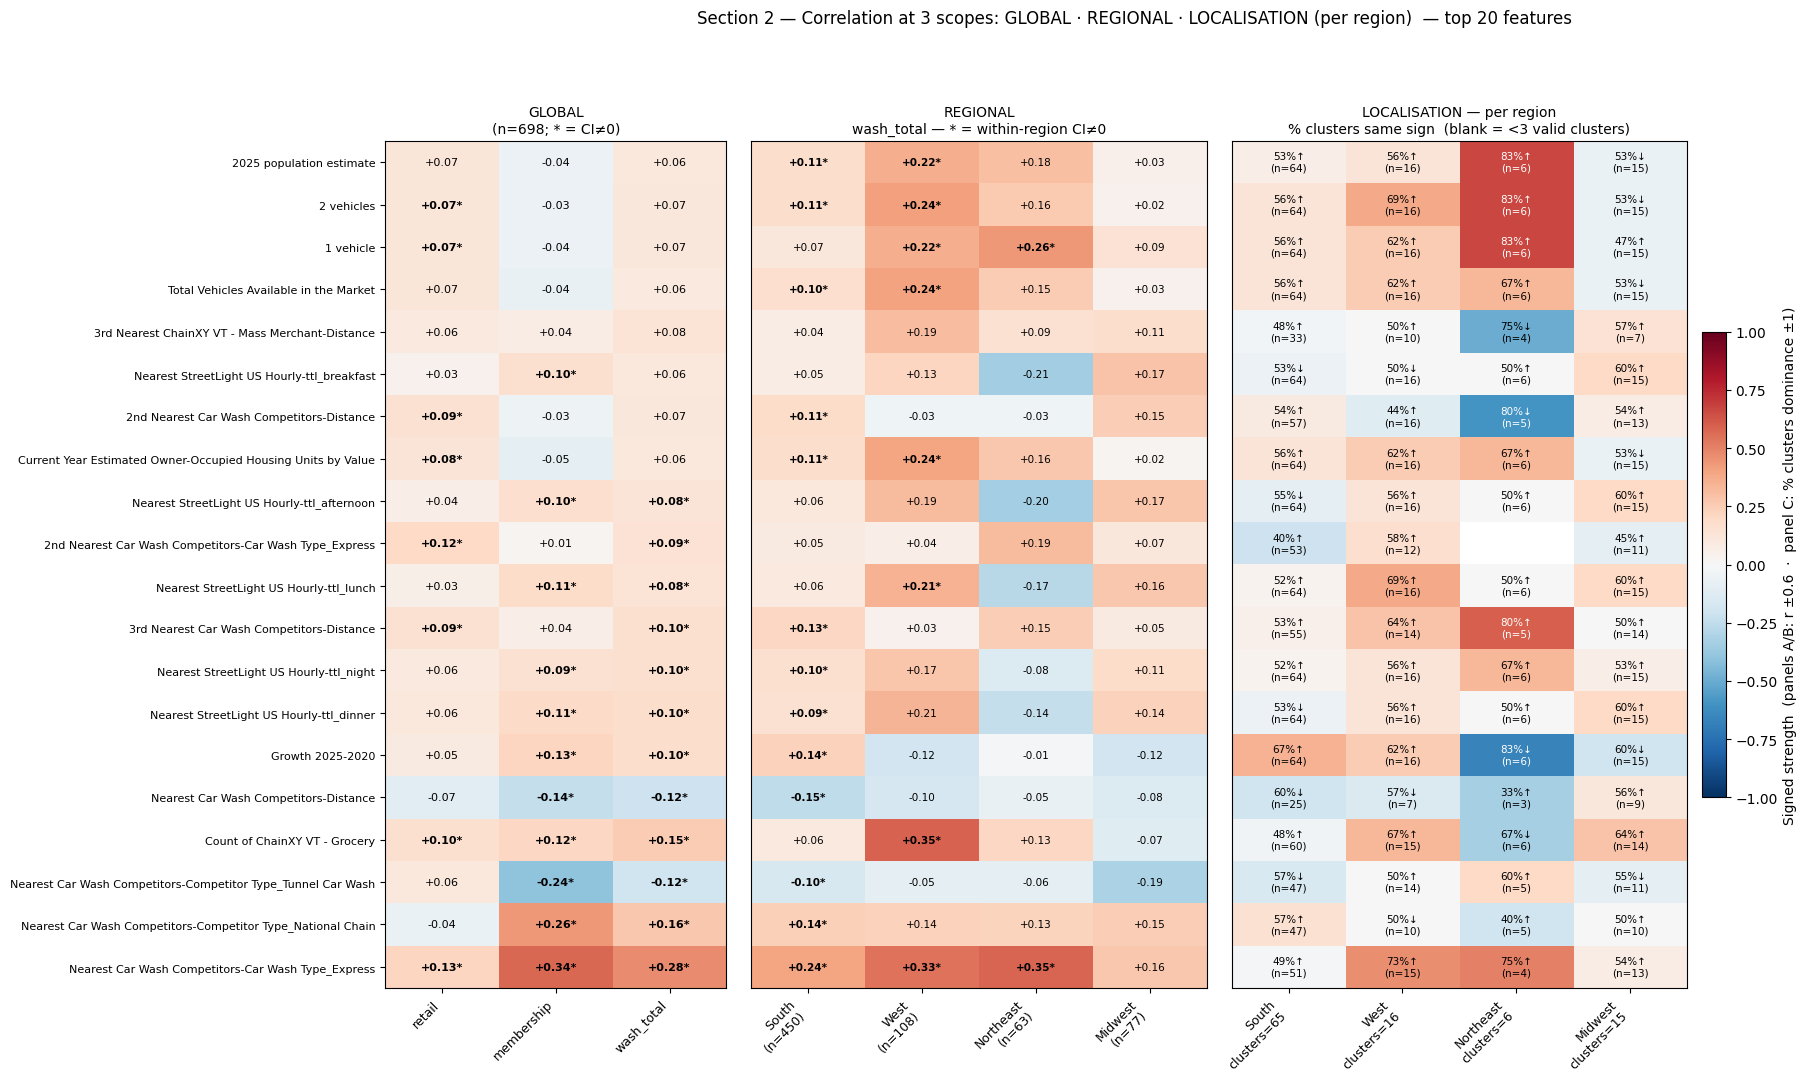

Features with regional signal AND aligned cluster majority (≥67% in same region):
  [Northeast:83%↑(n=6)]   2025 population estimate
  [West:69%↑(n=16), Northeast:83%↑(n=6)]   2 vehicles
  [Northeast:83%↑(n=6)]   1 vehicle
  [Northeast:75%↓(n=4)]   3rd Nearest ChainXY VT - Mass Merchant-Distance
  [Northeast:80%↓(n=5)]   2nd Nearest Car Wash Competitors-Distance
  [West:69%↑(n=16)]   Nearest StreetLight US Hourly-ttl_lunch
  [Northeast:80%↑(n=5)]   3rd Nearest Car Wash Competitors-Distance
  [South:67%↑(n=64), Northeast:83%↓(n=6)]   Growth 2025-2020
  [West:73%↑(n=15), Northeast:75%↑(n=4)]   Nearest Car Wash Competitors-Car Wash Type_Express

Global × Regional cross-scope tally:
  [R·L(Northeast)]  2025 population estimate
  [G·R·L(West,Northeast)]  2 vehicles
  [G·R·L(Northeast)]  1 vehicle
  [R]  Total Vehicles Available in the Market
  [L(Northeast)]  3rd Nearest ChainXY VT - Mass Merchant-Distance
  [G]  Nearest StreetLight US Hourly-ttl_breakfast
  [G·R·L(Northeast)]  2nd Nearest 

In [5]:
# ---- 0. Global Spearman r per feature × target ----
sp = pd.DataFrame({
    t: [spearmanr(X[c], targets[t]).statistic if X[c].std() > 0 else np.nan for c in X.columns]
    for t in targets.columns
}, index=X.columns)

TOP_N = 20
top = sp.abs().mean(axis=1).sort_values(ascending=False).head(TOP_N).index[::-1].tolist()

# ---- 1. Bootstrap CI helper ----
def bs_ci(x, y, n_boot=500, rng=None):
    rng = rng or np.random.default_rng(RANDOM_STATE)
    n = len(x); rs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        rs[i] = spearmanr(x[idx], y[idx]).statistic
    return np.percentile(rs, [2.5, 97.5])

global_ci_sig = {}
for t in targets.columns:
    yv = targets[t].values
    for f in top:
        lo, hi = bs_ci(X[f].values, yv)
        global_ci_sig[(f, t)] = (lo * hi) > 0

# ---- 2. PER REGION raw Spearman r (wash_total) ----
regions = ['South','West','Northeast','Midwest']
region_n = {r: int((region_col == r).sum()) for r in regions}
y_wt = targets['wash_total']
region_corr   = pd.DataFrame(index=top, columns=regions, dtype=float)
region_ci_sig = {}
for r in regions:
    m = (region_col == r).values
    yk = y_wt.values[m]
    for f in top:
        xk = X[f].values[m]
        if np.std(xk) == 0 or np.std(yk) == 0:
            region_corr.loc[f, r] = np.nan; region_ci_sig[(f, r)] = False; continue
        region_corr.loc[f, r] = spearmanr(xk, yk).statistic
        lo, hi = bs_ci(xk, yk, n_boot=300)
        region_ci_sig[(f, r)] = (lo * hi) > 0

# ---- 3. Per-cluster r for all 35 clusters, then aggregate PER REGION ----
clusters_all = sorted(loc_col.unique())
per_cluster = pd.DataFrame(index=top, columns=clusters_all, dtype=float)
for k in clusters_all:
    m = (loc_col == k).values
    yk = y_wt.values[m]
    if np.std(yk) == 0: continue
    for f in top:
        xk = X[f].values[m]
        if np.std(xk) == 0: continue
        per_cluster.loc[f, k] = spearmanr(xk, yk).statistic

cluster_to_region = df.groupby('localisation')['region'].agg(lambda s: s.mode().iloc[0]).to_dict()
region_clusters = {r: [k for k in clusters_all if cluster_to_region[k] == r] for r in regions}
n_clusters_per_region = {r: len(region_clusters[r]) for r in regions}

MIN_VALID = 3  # require ≥3 valid clusters in a region to show the cell
cons_score  = pd.DataFrame(index=top, columns=regions, dtype=float)
cons_sign   = pd.DataFrame(index=top, columns=regions, dtype=object)
cons_n      = pd.DataFrame(index=top, columns=regions, dtype=float)
cons_signed = pd.DataFrame(index=top, columns=regions, dtype=float)

for r in regions:
    cks = region_clusters[r]
    for f in top:
        vals = per_cluster.loc[f, cks].dropna().values
        nn = len(vals)
        cons_n.loc[f, r] = nn
        if nn < MIN_VALID:
            cons_score.loc[f, r] = np.nan
            cons_sign.loc[f, r]  = 'na'
            cons_signed.loc[f, r] = np.nan
            continue
        pos = int((vals > 0).sum()); neg = int((vals < 0).sum())
        dom_count = max(pos, neg)
        dom_sign  = 'pos' if pos >= neg else 'neg'
        pct = dom_count / nn
        cons_score.loc[f, r] = pct
        cons_sign.loc[f, r]  = dom_sign
        mag = (pct - 0.5) * 2
        cons_signed.loc[f, r] = mag if dom_sign == 'pos' else -mag

# ---- Plot: 3 panels (all heatmaps) ----
fig = plt.figure(figsize=(20, max(9, 0.45 * TOP_N + 2)))
gs = fig.add_gridspec(1, 3, width_ratios=[1.5, 2.0, 2.0], wspace=0.06)

def draw_heatmap(ax, mat, col_labels, row_labels, title, annotate_fn, vmin=-0.6, vmax=0.6):
    ax.imshow(mat, cmap='RdBu_r', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, fontsize=9, rotation=45, ha='right')
    if row_labels is not None:
        ax.set_yticks(range(len(row_labels))); ax.set_yticklabels(row_labels, fontsize=8)
    else:
        ax.set_yticks([])
    for (i, j), v in np.ndenumerate(mat):
        if np.isnan(v): continue
        annotate_fn(ax, i, j, v, vmax)
    ax.set_title(title, fontsize=10)

# A: GLOBAL heatmap
ax_a = fig.add_subplot(gs[0])
matA = sp.loc[top, ['retail','membership','wash_total']].values.astype(float)
def annotate_global(ax, i, j, v, vmax):
    f = top[i]; t = ['retail','membership','wash_total'][j]
    sig = global_ci_sig.get((f, t), False)
    label = f'{v:+.2f}' + ('*' if sig else '')
    ax.text(j, i, label, ha='center', va='center', fontsize=8,
            color='white' if abs(v) > vmax * 0.6 else 'black',
            fontweight='bold' if sig else 'normal')
draw_heatmap(
    ax_a, matA,
    col_labels=['retail','membership','wash_total'],
    row_labels=top,
    title=f'GLOBAL\n(n={len(X)}; * = CI≠0)',
    annotate_fn=annotate_global,
)

# B: REGIONAL heatmap
ax_b = fig.add_subplot(gs[1])
matB = region_corr.values.astype(float)
def annotate_region(ax, i, j, v, vmax):
    f = top[i]; r = regions[j]
    sig = region_ci_sig.get((f, r), False)
    label = f'{v:+.2f}' + ('*' if sig else '')
    ax.text(j, i, label, ha='center', va='center', fontsize=7.5,
            color='white' if abs(v) > vmax * 0.6 else 'black',
            fontweight='bold' if sig else 'normal')
draw_heatmap(
    ax_b, matB,
    col_labels=[f'{r}\n(n={region_n[r]})' for r in regions],
    row_labels=None,
    title='REGIONAL\nwash_total — * = within-region CI≠0',
    annotate_fn=annotate_region,
)

# C: LOCALISATION — per region
ax_c = fig.add_subplot(gs[2])
matC = cons_signed.values.astype(float)
def annotate_local(ax, i, j, v, vmax):
    pct = cons_score.iloc[i, j]
    nn  = int(cons_n.iloc[i, j])
    sign = cons_sign.iloc[i, j]
    if np.isnan(pct):
        return
    arrow = '↑' if sign == 'pos' else '↓'
    label = f'{pct:.0%}{arrow}\n(n={nn})'
    ax.text(j, i, label, ha='center', va='center', fontsize=7.5,
            color='white' if abs(v) > 0.6 else 'black')
draw_heatmap(
    ax_c, matC,
    col_labels=[f'{r}\nclusters={n_clusters_per_region[r]}' for r in regions],
    row_labels=None,
    title='LOCALISATION — per region\n% clusters same sign  (blank = <3 valid clusters)',
    annotate_fn=annotate_local,
    vmin=-1, vmax=1,
)

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-1, vmax=1))
fig.colorbar(sm, ax=fig.axes, shrink=0.55, pad=0.01,
             label='Signed strength  (panels A/B: r ±0.6  ·  panel C: % clusters dominance ±1)')

fig.suptitle(f'Section 2 — Correlation at 3 scopes: GLOBAL · REGIONAL · LOCALISATION (per region)  — top {TOP_N} features',
             fontsize=12, y=1.00)
plt.show()

# ---- Cross-scope summary ----
def has_global_sig(f): return any(global_ci_sig.get((f, t), False) for t in targets.columns)
def has_region_sig(f): return any(region_ci_sig.get((f, r), False) for r in regions)
def region_with_strong_clusters(f, threshold=0.67):
    out = []
    for r in regions:
        pct = cons_score.loc[f, r]
        if not np.isnan(pct) and pct >= threshold:
            out.append((r, cons_sign.loc[f, r], cons_score.loc[f, r], int(cons_n.loc[f, r])))
    return out

print('Features with regional signal AND aligned cluster majority (≥67% in same region):')
hits = []
for f in top:
    strong = region_with_strong_clusters(f)
    if strong:
        details = ', '.join(f'{r}:{p:.0%}{"↑" if s=="pos" else "↓"}(n={n})' for r, s, p, n in strong)
        hits.append((f, details))
if hits:
    for f, details in hits:
        print(f'  [{details}]   {f}')
else:
    print('  (none)')

print('\nGlobal × Regional cross-scope tally:')
for f in top:
    flags = []
    if has_global_sig(f):  flags.append('G')
    if has_region_sig(f):  flags.append('R')
    strong = region_with_strong_clusters(f)
    if strong: flags.append('L(' + ','.join(r for r, _, _, _ in strong) + ')')
    if flags:
        print(f'  [{ "·".join(flags) }]  {f}')

## 3. SHAP feature importance — global · regional

Univariate correlations in Section 2 miss interactions and non-linear effects. **SHAP** (Shapley Additive Explanations) gives a multivariate, model-aware view: for each prediction, how much did each feature push it up or down? Aggregating across sites produces per-feature importance that handles correlated features better than permutation importance.

**Scope — 3-mile-environment features only.** The site's own age (`age_on_30_sep_25`) and operational start date are *excluded* upstream in the feature-matrix cell: they describe site maturity, not the surrounding market, and age otherwise dominated every panel (it hit 100% in nearly every regional cell). What remains is what a site-selection model can actually use — demographics, traffic, nearby retail anchors, and competitors. Feature labels are humanized for readability (raw column names mapped via `FEATURE_LABELS`).

Six panels (2 rows × 3 columns), top 15 features (ranked by global wash_total SHAP):

- **Top row — GLOBAL** SHAP for each target (retail, membership, wash_total) from a RandomForest fit on all sites. Bar length = mean |SHAP value|. **Bar color = direction**: blue = feature value going up → prediction goes up; red = feature value up → prediction down.
- **Bottom row — REGIONAL** SHAP heatmap for each target: fit a separate RF per region, normalize each region's top SHAP feature to 100%. Color encodes signed importance (blue/red = direction). Shows which features matter most *within each region*, per target.

**Caveat:** West (n=108), Midwest (n=77), and Northeast (n=63) have far fewer sites than South — small samples give noisier SHAP rankings. Treat the South column (n=450) as most reliable; the others as suggestive.

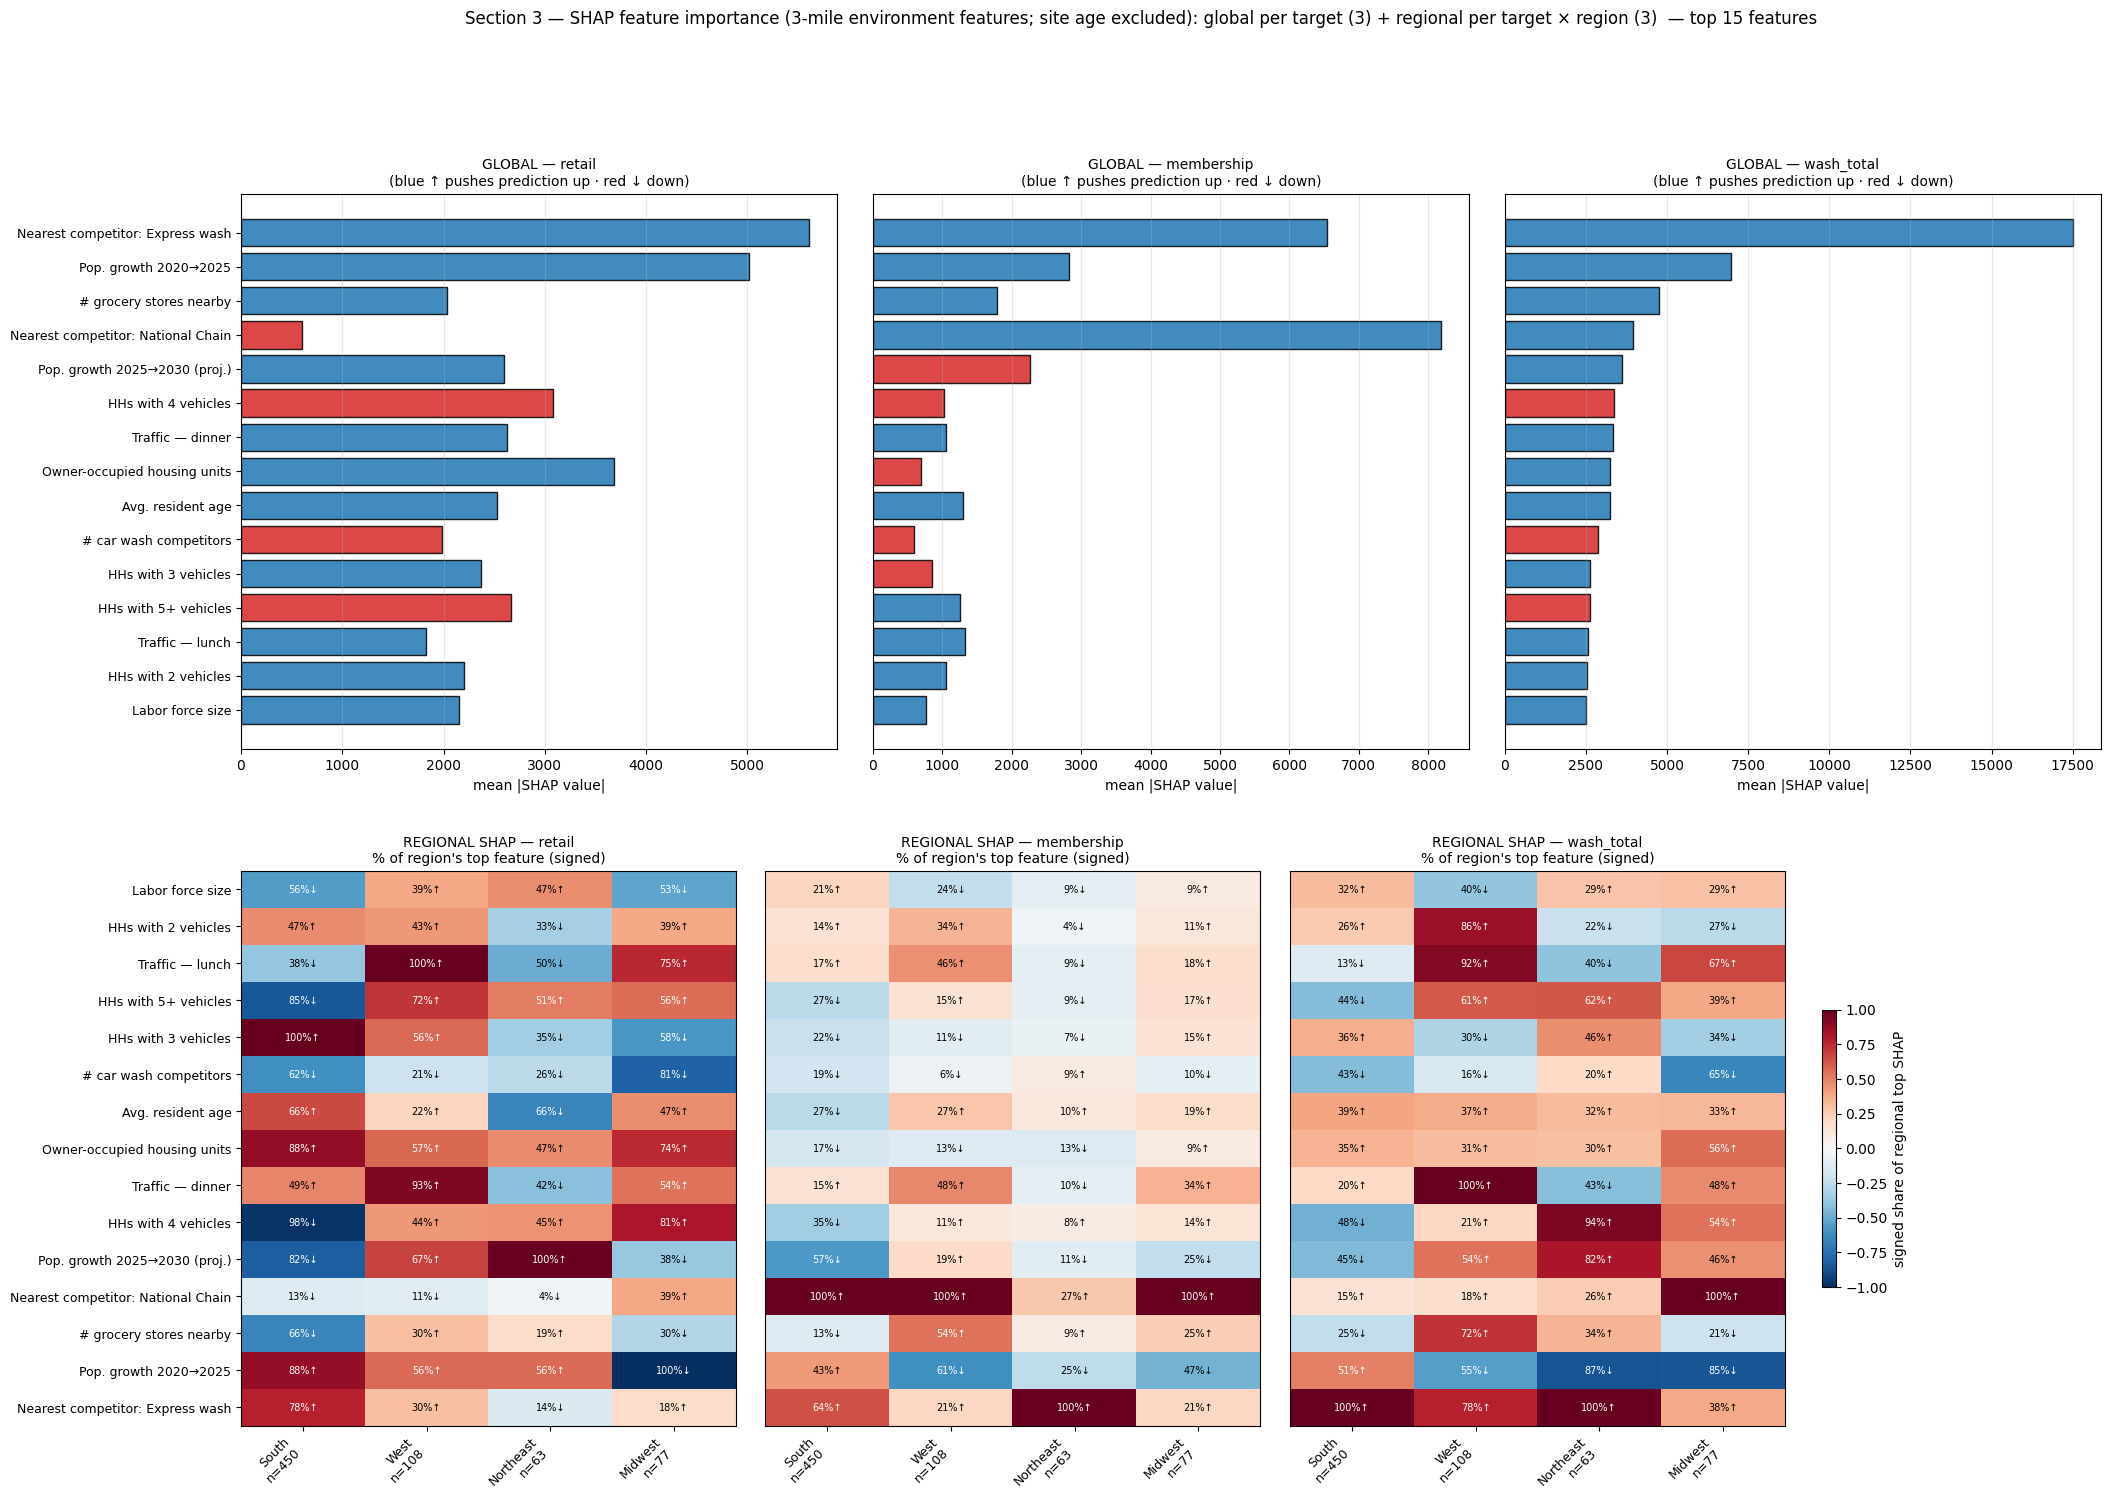

Top 10 SHAP features for retail (global):
  ↑     5606.4  Nearest competitor: Express wash
  ↑     5015.3  Pop. growth 2020→2025
  ↑     3682.3  Owner-occupied housing units
  ↓     3078.5  HHs with 4 vehicles
  ↓     2665.2  HHs with 5+ vehicles
  ↑     2630.6  Traffic — dinner
  ↑     2598.2  Pop. growth 2025→2030 (proj.)
  ↑     2527.8  Avg. resident age
  ↑     2370.0  HHs with 3 vehicles
  ↑     2236.6  Population (2025 est.)

Top 10 SHAP features for membership (global):
  ↑     8178.6  Nearest competitor: National Chain
  ↑     6535.8  Nearest competitor: Express wash
  ↓     6270.5  Nearest competitor: Tunnel Car Wash
  ↑     2825.8  Pop. growth 2020→2025
  ↓     2256.7  Pop. growth 2025→2030 (proj.)
  ↑     1787.7  # grocery stores nearby
  ↓     1468.8  HHs earning $150–175k
  ↑     1332.7  Traffic — lunch
  ↑     1295.7  Avg. resident age
  ↑     1260.1  HHs with 5+ vehicles

Top 10 SHAP features for wash_total (global):
  ↑    17496.8  Nearest competitor: Express wash
  ↑  

In [6]:
import re

def shap_direction(X_col_vals, shap_col_vals):
    """Spearman corr between feature value and its SHAP value.
       +1 = higher feature value → higher prediction; -1 = higher value → lower prediction."""
    if np.std(X_col_vals) == 0 or np.std(shap_col_vals) == 0:
        return 0
    r = spearmanr(X_col_vals, shap_col_vals).statistic
    return r if not np.isnan(r) else 0

def fit_shap(X_data, y_data):
    rf = RandomForestRegressor(n_estimators=400, max_features='sqrt', min_samples_leaf=2,
                               random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_data, y_data)
    expl = shap.TreeExplainer(rf)
    sv = expl.shap_values(X_data, check_additivity=False)
    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=X_data.columns)
    dirn = pd.Series(
        [shap_direction(X_data.iloc[:, i].values, sv[:, i]) for i in range(X_data.shape[1])],
        index=X_data.columns,
    )
    return mean_abs, np.sign(dirn).astype(int)

# Site age & open-date are excluded upstream in the feature-matrix cell, so X is already
# environment-only. Alias kept to make this section's scope explicit.
X_shap = X

# ---- Human-readable feature labels for the y-axis ----
FEATURE_LABELS = {
    '2025 population estimate': 'Population (2025 est.)',
    'Growth 2025-2020': 'Pop. growth 2020→2025',
    'Growth 2030-2025': 'Pop. growth 2025→2030 (proj.)',
    '2025 Average Age': 'Avg. resident age',
    'Labor Force': 'Labor force size',
    'Average Household Income': 'Avg. household income',
    'Median Household Income': 'Median household income',
    'Renter-Occupied': 'Renter-occupied housing',
    '1 vehicle': 'HHs with 1 vehicle',
    '2 vehicles': 'HHs with 2 vehicles',
    '3 vehicles': 'HHs with 3 vehicles',
    '4 vehicles': 'HHs with 4 vehicles',
    '5 or more vehicles': 'HHs with 5+ vehicles',
    'Total Vehicles Available in the Market': 'Total vehicles in market',
    'Average Number of Vehicles Available': 'Avg. vehicles per HH',
    'Current Year Estimated Owner-Occupied Housing Units by Value': 'Owner-occupied housing units',
    'Count of Car Wash Competitors': '# car wash competitors',
    'Count of ChainXY VT - Mass Merchant': '# mass merchants nearby',
    'Count of ChainXY VT - Grocery': '# grocery stores nearby',
    'Count of ChainXY VT - Department Store': '# dept. stores nearby',
    'Nearest ChainXY VT - Mass Merchant-Distance': 'Dist. to mass merchant',
    'Nearest Car Wash Competitors-Distance': 'Dist. to nearest car wash',
    '2nd Nearest Car Wash Competitors-Distance': 'Dist. to 2nd car wash',
    '3rd Nearest Car Wash Competitors-Distance': 'Dist. to 3rd car wash',
    'Nearest StreetLight US Hourly-ttl_overnight': 'Traffic — overnight',
    'Nearest StreetLight US Hourly-ttl_breakfast': 'Traffic — breakfast',
    'Nearest StreetLight US Hourly-ttl_lunch': 'Traffic — lunch',
    'Nearest StreetLight US Hourly-ttl_afternoon': 'Traffic — afternoon',
    'Nearest StreetLight US Hourly-ttl_dinner': 'Traffic — dinner',
    'Nearest StreetLight US Hourly-ttl_night': 'Traffic — night',
    'Nearest StreetLight US Hourly-Highway': 'Traffic — highway',
    '2025 % HH  with Income $50K+': '% HHs income $50K+',
    '$100,000 to $124,999': 'HHs earning $100–125k',
    '$125,000 to $149,999': 'HHs earning $125–150k',
    '$150,000 to $174,999': 'HHs earning $150–175k',
    '$175,000 to $199,999': 'HHs earning $175–200k',
    '$200,000 to $249,999': 'HHs earning $200–250k',
}

def feat_label(col):
    if col in FEATURE_LABELS:
        return FEATURE_LABELS[col]
    # one-hot competitor dummies: "[rank ]Nearest Car Wash Competitors-<Competitor Type|Car Wash Type>_<value>"
    m = re.match(r'(?:(\d+(?:st|nd|rd|th)) )?Nearest Car Wash Competitors-(Competitor Type|Car Wash Type)_(.+)$', col)
    if m:
        rank = m.group(1) or 'Nearest'
        val  = m.group(3)
        return f'{rank} competitor: {val}' + (' wash' if m.group(2) == 'Car Wash Type' else '')
    return col

TARGET_NAMES = ['retail', 'membership', 'wash_total']

# ---- Global SHAP (one RF per target) ----
shap_imp  = {}
shap_sign = {}
for name in TARGET_NAMES:
    imp, sign = fit_shap(X_shap, targets[name])
    shap_imp[name]  = imp
    shap_sign[name] = sign

# ---- Regional SHAP (one RF per region, per target) ----
# regional_shap_imp[name] / regional_shap_sign[name] -> DataFrame [features x regions]
regional_shap_imp  = {}
regional_shap_sign = {}
for name in TARGET_NAMES:
    imp_df  = pd.DataFrame(index=X_shap.columns, columns=regions, dtype=float)
    sign_df = pd.DataFrame(index=X_shap.columns, columns=regions, dtype=int)
    for r in regions:
        m = (region_col == r).values
        imp, sign = fit_shap(X_shap[m], targets[name][m])
        imp_df[r]  = imp
        sign_df[r] = sign
    regional_shap_imp[name]  = imp_df
    regional_shap_sign[name] = sign_df

# ---- Top features (ranked by global wash_total SHAP; site age already excluded) ----
TOP_N = 15
top_shap = shap_imp['wash_total'].sort_values(ascending=False).head(TOP_N).index[::-1].tolist()
top_labels = [feat_label(f) for f in top_shap]

# ---- Plot: 2 rows x 3 cols (top = global bars per target, bottom = regional heatmaps per target) ----
fig = plt.figure(figsize=(24, max(8, 0.4 * TOP_N + 1) * 2))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.0], wspace=0.06, hspace=0.22)

# ---- Row 0: global SHAP bars per target ----
for col, name in enumerate(TARGET_NAMES):
    ax = fig.add_subplot(gs[0, col])
    imp = shap_imp[name].loc[top_shap].values
    sign = shap_sign[name].loc[top_shap].values
    bar_colors = ['#1f77b4' if s > 0 else '#d62728' if s < 0 else '#999999' for s in sign]
    ax.barh(range(len(top_shap)), imp, color=bar_colors, alpha=0.85, edgecolor='black')
    if col == 0:
        ax.set_yticks(range(len(top_shap)))
        ax.set_yticklabels(top_labels, fontsize=9)
    else:
        ax.set_yticks([])
    ax.set_xlabel('mean |SHAP value|')
    ax.set_title(f'GLOBAL — {name}\n(blue ↑ pushes prediction up · red ↓ down)', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

# ---- Row 1: regional SHAP heatmaps per target ----
for col, name in enumerate(TARGET_NAMES):
    ax = fig.add_subplot(gs[1, col])
    reg_imp_norm = regional_shap_imp[name].loc[top_shap].copy()
    for r in regions:
        mx = reg_imp_norm[r].max()
        if mx and not np.isnan(mx) and mx > 0:
            reg_imp_norm[r] = reg_imp_norm[r] / mx
    reg_signed = reg_imp_norm * regional_shap_sign[name].loc[top_shap]
    mat = reg_signed.values.astype(float)

    ax.imshow(mat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(regions)))
    ax.set_xticklabels([f'{r}\nn={region_n[r]}' for r in regions], fontsize=9, rotation=45, ha='right')
    if col == 0:
        ax.set_yticks(range(len(top_shap)))
        ax.set_yticklabels(top_labels, fontsize=9)
    else:
        ax.set_yticks([])
    for (i, j), v in np.ndenumerate(mat):
        if np.isnan(v): continue
        pct = abs(v) * 100
        arrow = '↑' if v > 0 else ('↓' if v < 0 else '·')
        ax.text(j, i, f'{pct:.0f}%{arrow}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 0.5 else 'black')
    ax.set_title(f'REGIONAL SHAP — {name}\n% of region\'s top feature (signed)', fontsize=10)

sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-1, vmax=1))
fig.colorbar(sm, ax=fig.axes[3:], shrink=0.5, pad=0.02, label='signed share of regional top SHAP')

fig.suptitle(f'Section 3 — SHAP feature importance (3-mile environment features; site age excluded): '
             f'global per target (3) + regional per target × region (3)  — top {TOP_N} features',
             fontsize=12, y=0.995)
plt.show()

# ---- Summary ----
for name in TARGET_NAMES:
    print(f'Top 10 SHAP features for {name} (global):')
    for f, v in shap_imp[name].sort_values(ascending=False).head(10).items():
        s = shap_sign[name].loc[f]
        arrow = '↑' if s > 0 else ('↓' if s < 0 else '·')
        print(f'  {arrow} {v:>10.1f}  {feat_label(f)}')
    print()

print('Features in top-15 SHAP for ALL three global targets:')
shared = set(shap_imp['retail'].sort_values(ascending=False).head(15).index) & \
         set(shap_imp['membership'].sort_values(ascending=False).head(15).index) & \
         set(shap_imp['wash_total'].sort_values(ascending=False).head(15).index)
for f in sorted(shared): print(f'  - {feat_label(f)}')

print(f'\nFeatures appearing in top-5 SHAP for South region (n={region_n["South"]}, most reliable):')
for name in TARGET_NAMES:
    print(f'  [{name}]')
    top5_south = regional_shap_imp[name]['South'].sort_values(ascending=False).head(5).index.tolist()
    for f in top5_south:
        s = regional_shap_sign[name].loc[f, 'South']
        arrow = '↑' if s > 0 else '↓'
        val = regional_shap_imp[name].loc[f, 'South']
        print(f'    {arrow} {val:>10.1f}  {feat_label(f)}')


## 4. Localisation-level importance — between vs within neighborhood clusters

Section 3's noise-floor test showed the **region** split is indistinguishable from sampling noise — but the Section 1 variance decomposition puts ~33% of wash-volume variance at the **localisation-cluster** (neighborhood) level. We can't fit SHAP *inside* each of the 102 clusters — most hold only 2–8 sites — so we model at the **cluster scale** two complementary ways, using the 92 clusters with ≥3 sites (678/698 sites; far more robust than the 4 regions):

- **Top row — BETWEEN-cluster.** Collapse each cluster to its mean (one row per neighborhood) and fit SHAP. Answers *"what makes a neighborhood high-volume?"* — the ~33% of variance. *(Ecological/aggregate relationship: valid for characterizing neighborhoods, not a site-level causal claim.)*
- **Bottom row — WITHIN-cluster.** Subtract each cluster's mean from `X` and `y` (a fixed-effects transform) and fit SHAP on the residuals. Answers *"holding the neighborhood fixed, what pushes one site above its neighbors?"*

Each row is ranked by its **own** level's wash_total importance — the takeaway is that the drivers differ by level (global importance ≈ between + within, mixed). Same humanized labels and directional colors as Section 3 (blue ↑ pushes prediction up, red ↓ down).

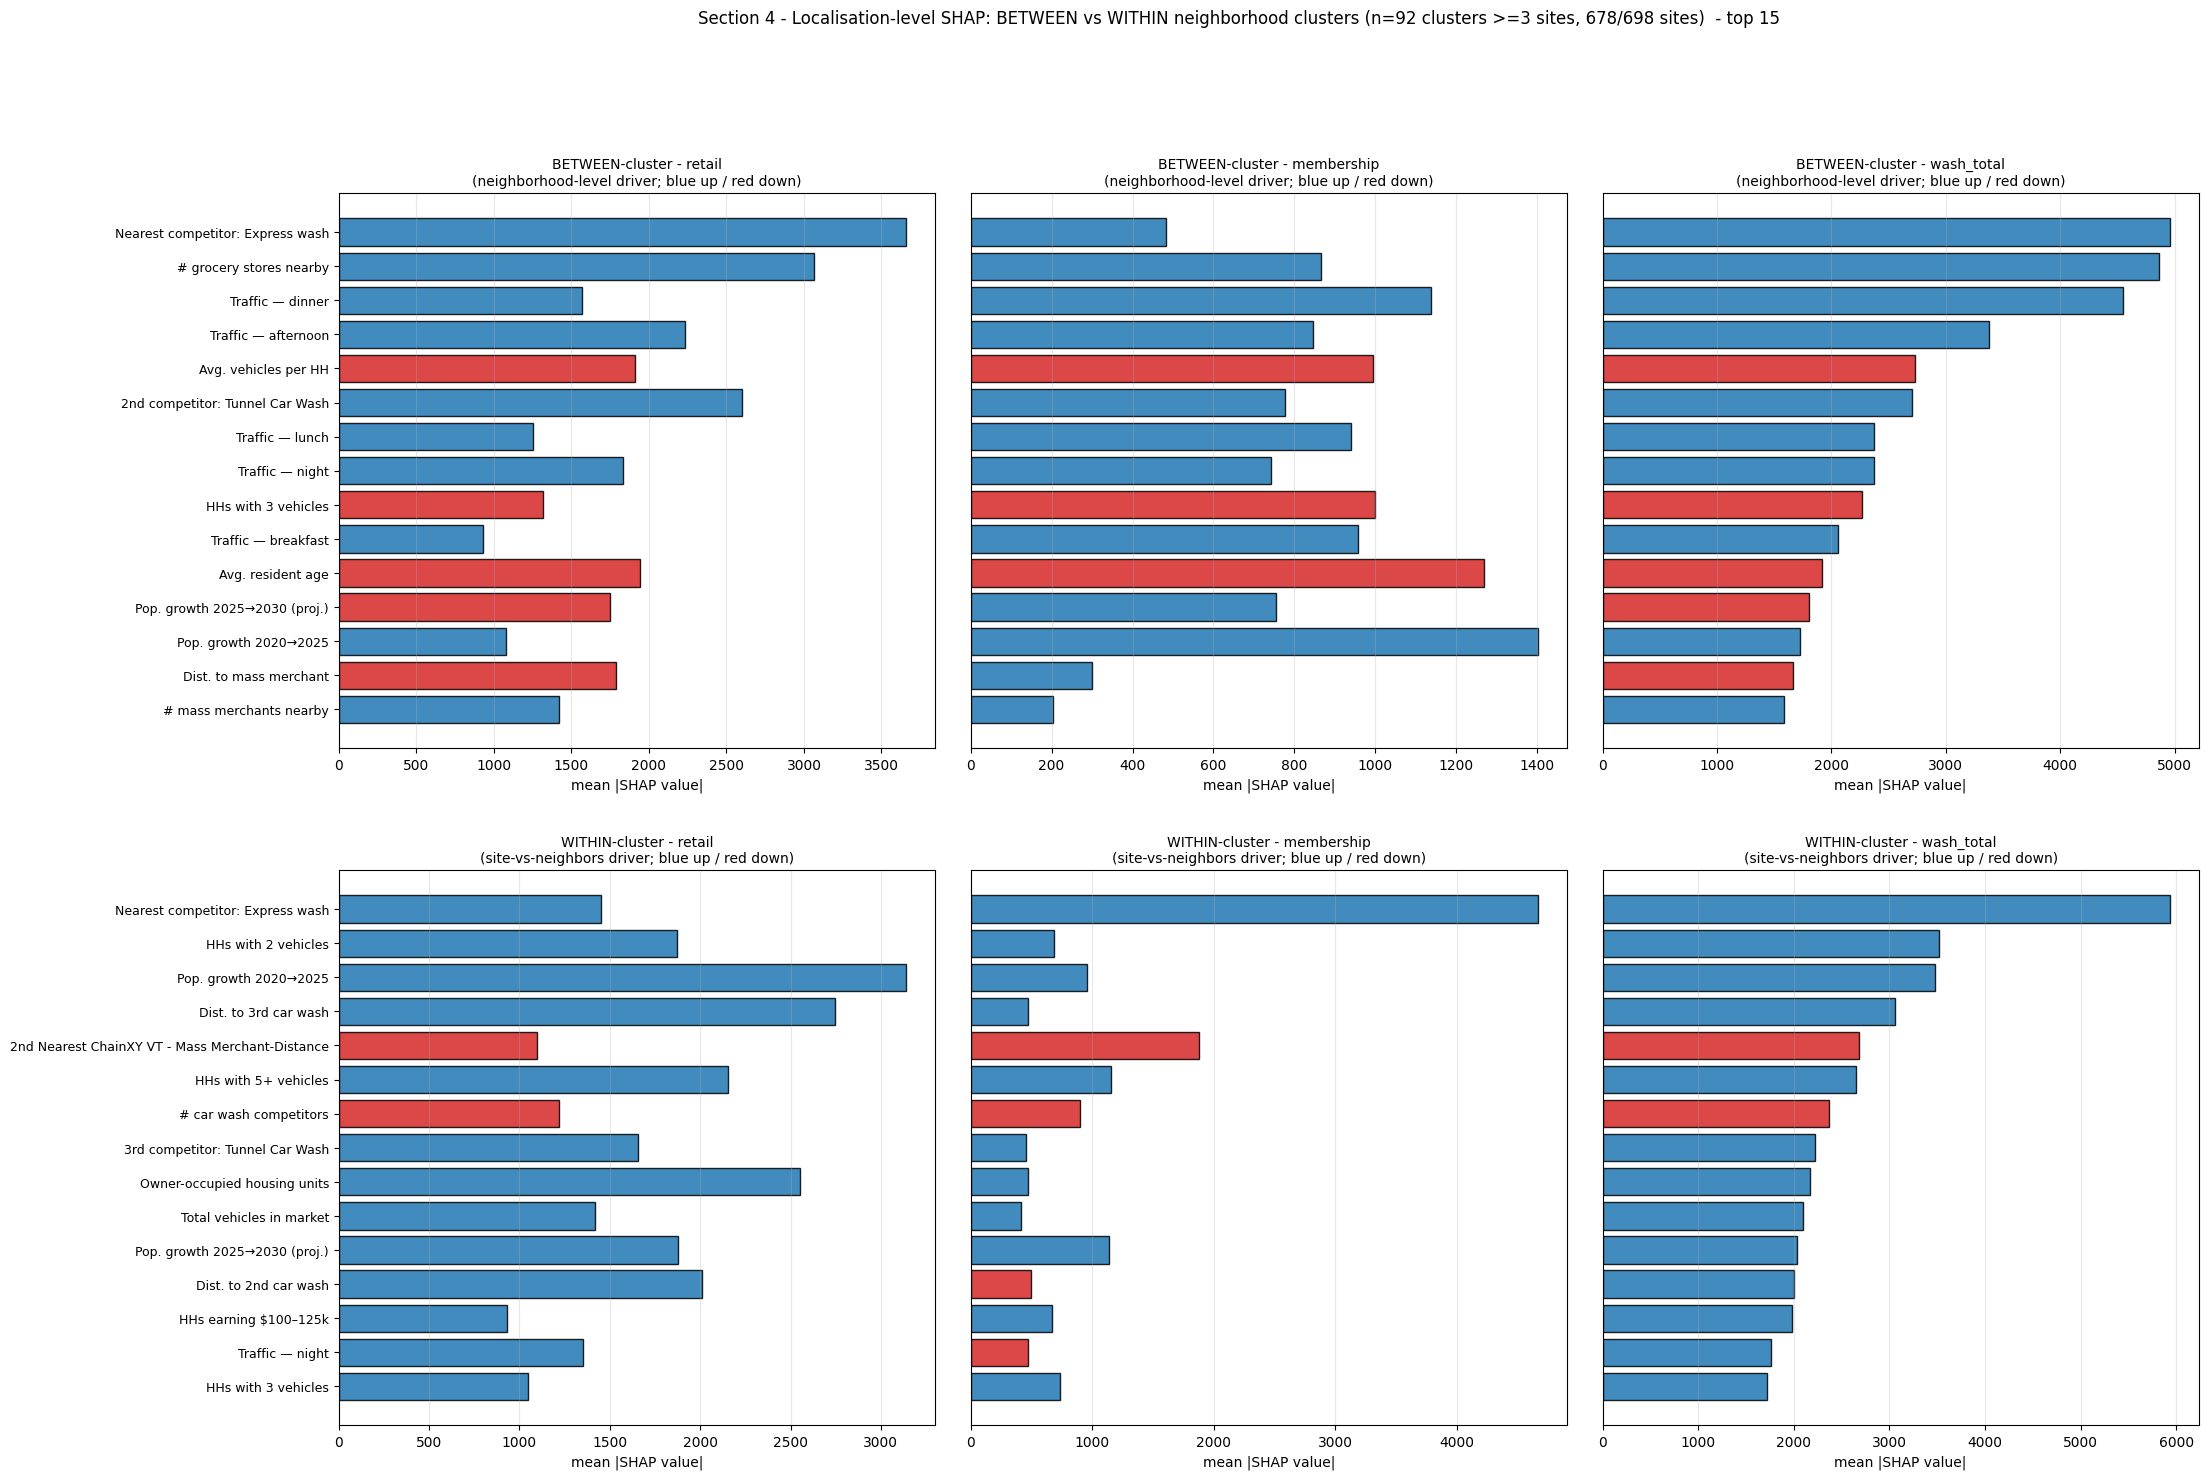

Clusters used: 92 (>= 3 sites), covering 678/698 sites

[    retail] rank-corr global-vs-between=+0.06  global-vs-within=+0.38  importance within/between=1.17
[membership] rank-corr global-vs-between=+0.58  global-vs-within=+0.53  importance within/between=1.29
[wash_total] rank-corr global-vs-between=+0.34  global-vs-within=+0.43  importance within/between=1.09

BETWEEN-cluster - top 6 for wash_total:
  up        4964  Nearest competitor: Express wash
  up        4869  # grocery stores nearby
  up        4546  Traffic — dinner
  up        3377  Traffic — afternoon
  down      2730  Avg. vehicles per HH
  up        2705  2nd competitor: Tunnel Car Wash

WITHIN-cluster - top 6 for wash_total:
  up        5937  Nearest competitor: Express wash
  up        3514  HHs with 2 vehicles
  up        3477  Pop. growth 2020→2025
  up        3056  Dist. to 3rd car wash
  down      2685  2nd Nearest ChainXY VT - Mass Merchant-Distance
  up        2649  HHs with 5+ vehicles



In [7]:
# ============================================================================
# Section 4 — Localisation-level SHAP: BETWEEN vs WITHIN neighborhood clusters
# ============================================================================
# Region was noise (Section 3 test); the signal lives at the localisation-cluster level
# (~33% of variance). Can't SHAP each of the 102 clusters (most have 2-8 sites), so model
# at the CLUSTER SCALE two ways, using clusters with >=3 sites (n=92, 678/698 sites):
#   BETWEEN -> collapse each cluster to its mean (1 row/cluster): what makes a NEIGHBORHOOD high-volume
#   WITHIN  -> subtract each cluster's mean (fixed effects): what moves a SITE above its neighbors
# Reuses fit_shap / feat_label / TARGET_NAMES / shap_imp from Section 3.

MIN_CLUSTER = 3
vc = loc_col.value_counts()
big_clusters = vc[vc >= MIN_CLUSTER].index
cmask = loc_col.isin(big_clusters).values
loc_big = loc_col[cmask]
n_clusters_used = len(big_clusters)
n_sites_used = int(cmask.sum())

between_imp, between_sign = {}, {}
within_imp,  within_sign  = {}, {}
for name in TARGET_NAMES:
    y = targets[name]
    # BETWEEN: one row per cluster (cluster means)
    Xc = X[cmask].groupby(loc_big).mean()
    yc = y[cmask].groupby(loc_big).mean()
    between_imp[name], between_sign[name] = fit_shap(Xc.reset_index(drop=True), yc.reset_index(drop=True))
    # WITHIN: cluster-demeaned residuals (fixed effects)
    Xw = X[cmask].copy()
    Xw = Xw - Xw.groupby(loc_big).transform('mean')
    yw = y[cmask] - y[cmask].groupby(loc_big).transform('mean')
    within_imp[name], within_sign[name] = fit_shap(Xw.reset_index(drop=True), yw.reset_index(drop=True))

# Each row ranked by its OWN level's wash_total importance (between drivers != within drivers)
TOP_N = 15
top_between = between_imp['wash_total'].sort_values(ascending=False).head(TOP_N).index[::-1].tolist()
top_within  = within_imp['wash_total'].sort_values(ascending=False).head(TOP_N).index[::-1].tolist()

LEVELS = [
    ('BETWEEN-cluster', 'neighborhood-level driver', between_imp, between_sign, top_between),
    ('WITHIN-cluster',  'site-vs-neighbors driver',  within_imp,  within_sign,  top_within),
]

fig = plt.figure(figsize=(24, max(8, 0.4 * TOP_N + 1) * 2))
gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.0], wspace=0.06, hspace=0.22)

for row, (lvl, subtitle, imp_d, sign_d, order) in enumerate(LEVELS):
    labels = [feat_label(f) for f in order]
    for col, name in enumerate(TARGET_NAMES):
        ax = fig.add_subplot(gs[row, col])
        imp  = imp_d[name].loc[order].values
        sign = sign_d[name].loc[order].values
        bar_colors = ['#1f77b4' if s > 0 else '#d62728' if s < 0 else '#999999' for s in sign]
        ax.barh(range(len(order)), imp, color=bar_colors, alpha=0.85, edgecolor='black')
        if col == 0:
            ax.set_yticks(range(len(order))); ax.set_yticklabels(labels, fontsize=9)
        else:
            ax.set_yticks([])
        ax.set_xlabel('mean |SHAP value|')
        ax.set_title(f'{lvl} - {name}\n({subtitle}; blue up / red down)', fontsize=10)
        ax.grid(axis='x', alpha=0.3)

fig.suptitle(f'Section 4 - Localisation-level SHAP: BETWEEN vs WITHIN neighborhood clusters '
             f'(n={n_clusters_used} clusters >={MIN_CLUSTER} sites, {n_sites_used}/{len(df)} sites)  - top {TOP_N}',
             fontsize=12, y=0.995)
plt.show()

# ---- Summary: how different are the levels from the site-level global ranking? ----
print(f'Clusters used: {n_clusters_used} (>= {MIN_CLUSTER} sites), covering {n_sites_used}/{len(df)} sites\n')
for name in TARGET_NAMES:
    rc_b  = spearmanr(shap_imp[name], between_imp[name]).statistic
    rc_w  = spearmanr(shap_imp[name], within_imp[name]).statistic
    ratio = within_imp[name].sum() / between_imp[name].sum()
    print(f'[{name:>10}] rank-corr global-vs-between={rc_b:+.2f}  global-vs-within={rc_w:+.2f}  '
          f'importance within/between={ratio:.2f}')
print()
for lvl, _, imp_d, sign_d, order in LEVELS:
    print(f'{lvl} - top 6 for wash_total:')
    for f, v in imp_d['wash_total'].sort_values(ascending=False).head(6).items():
        s = sign_d['wash_total'].loc[f]
        print(f"  {'up  ' if s>0 else 'down'} {v:>9.0f}  {feat_label(f)}")
    print()

### 4b. Localisation decomposition, region-wise

The Section 4 between/within-cluster decomposition, now computed **separately inside each region** — each panel is ranked by its **own** top features (not forced to share a feature set). Layout: rows = region, cols = target.

**Read with the sample sizes stamped on every panel:**
- **Between-cluster** needs many clusters per region. Only **South (58 clusters)** genuinely supports it; **West (15)** and **Midwest (13)** are marginal (heavy overfit — suggestive only); **Northeast (6)** is not estimable and is blanked.
- **Within-cluster** uses each region's sites (clusters with ≥2 sites). South is solid; the smaller regions are noise-prone — Section 3's negative control showed region splits sit at the noise floor.

Net: **trust the South row**; the rest are shown for completeness. For a reliable neighborhood-level read use the pooled Section 4 (n=92 clusters), not these region splits.

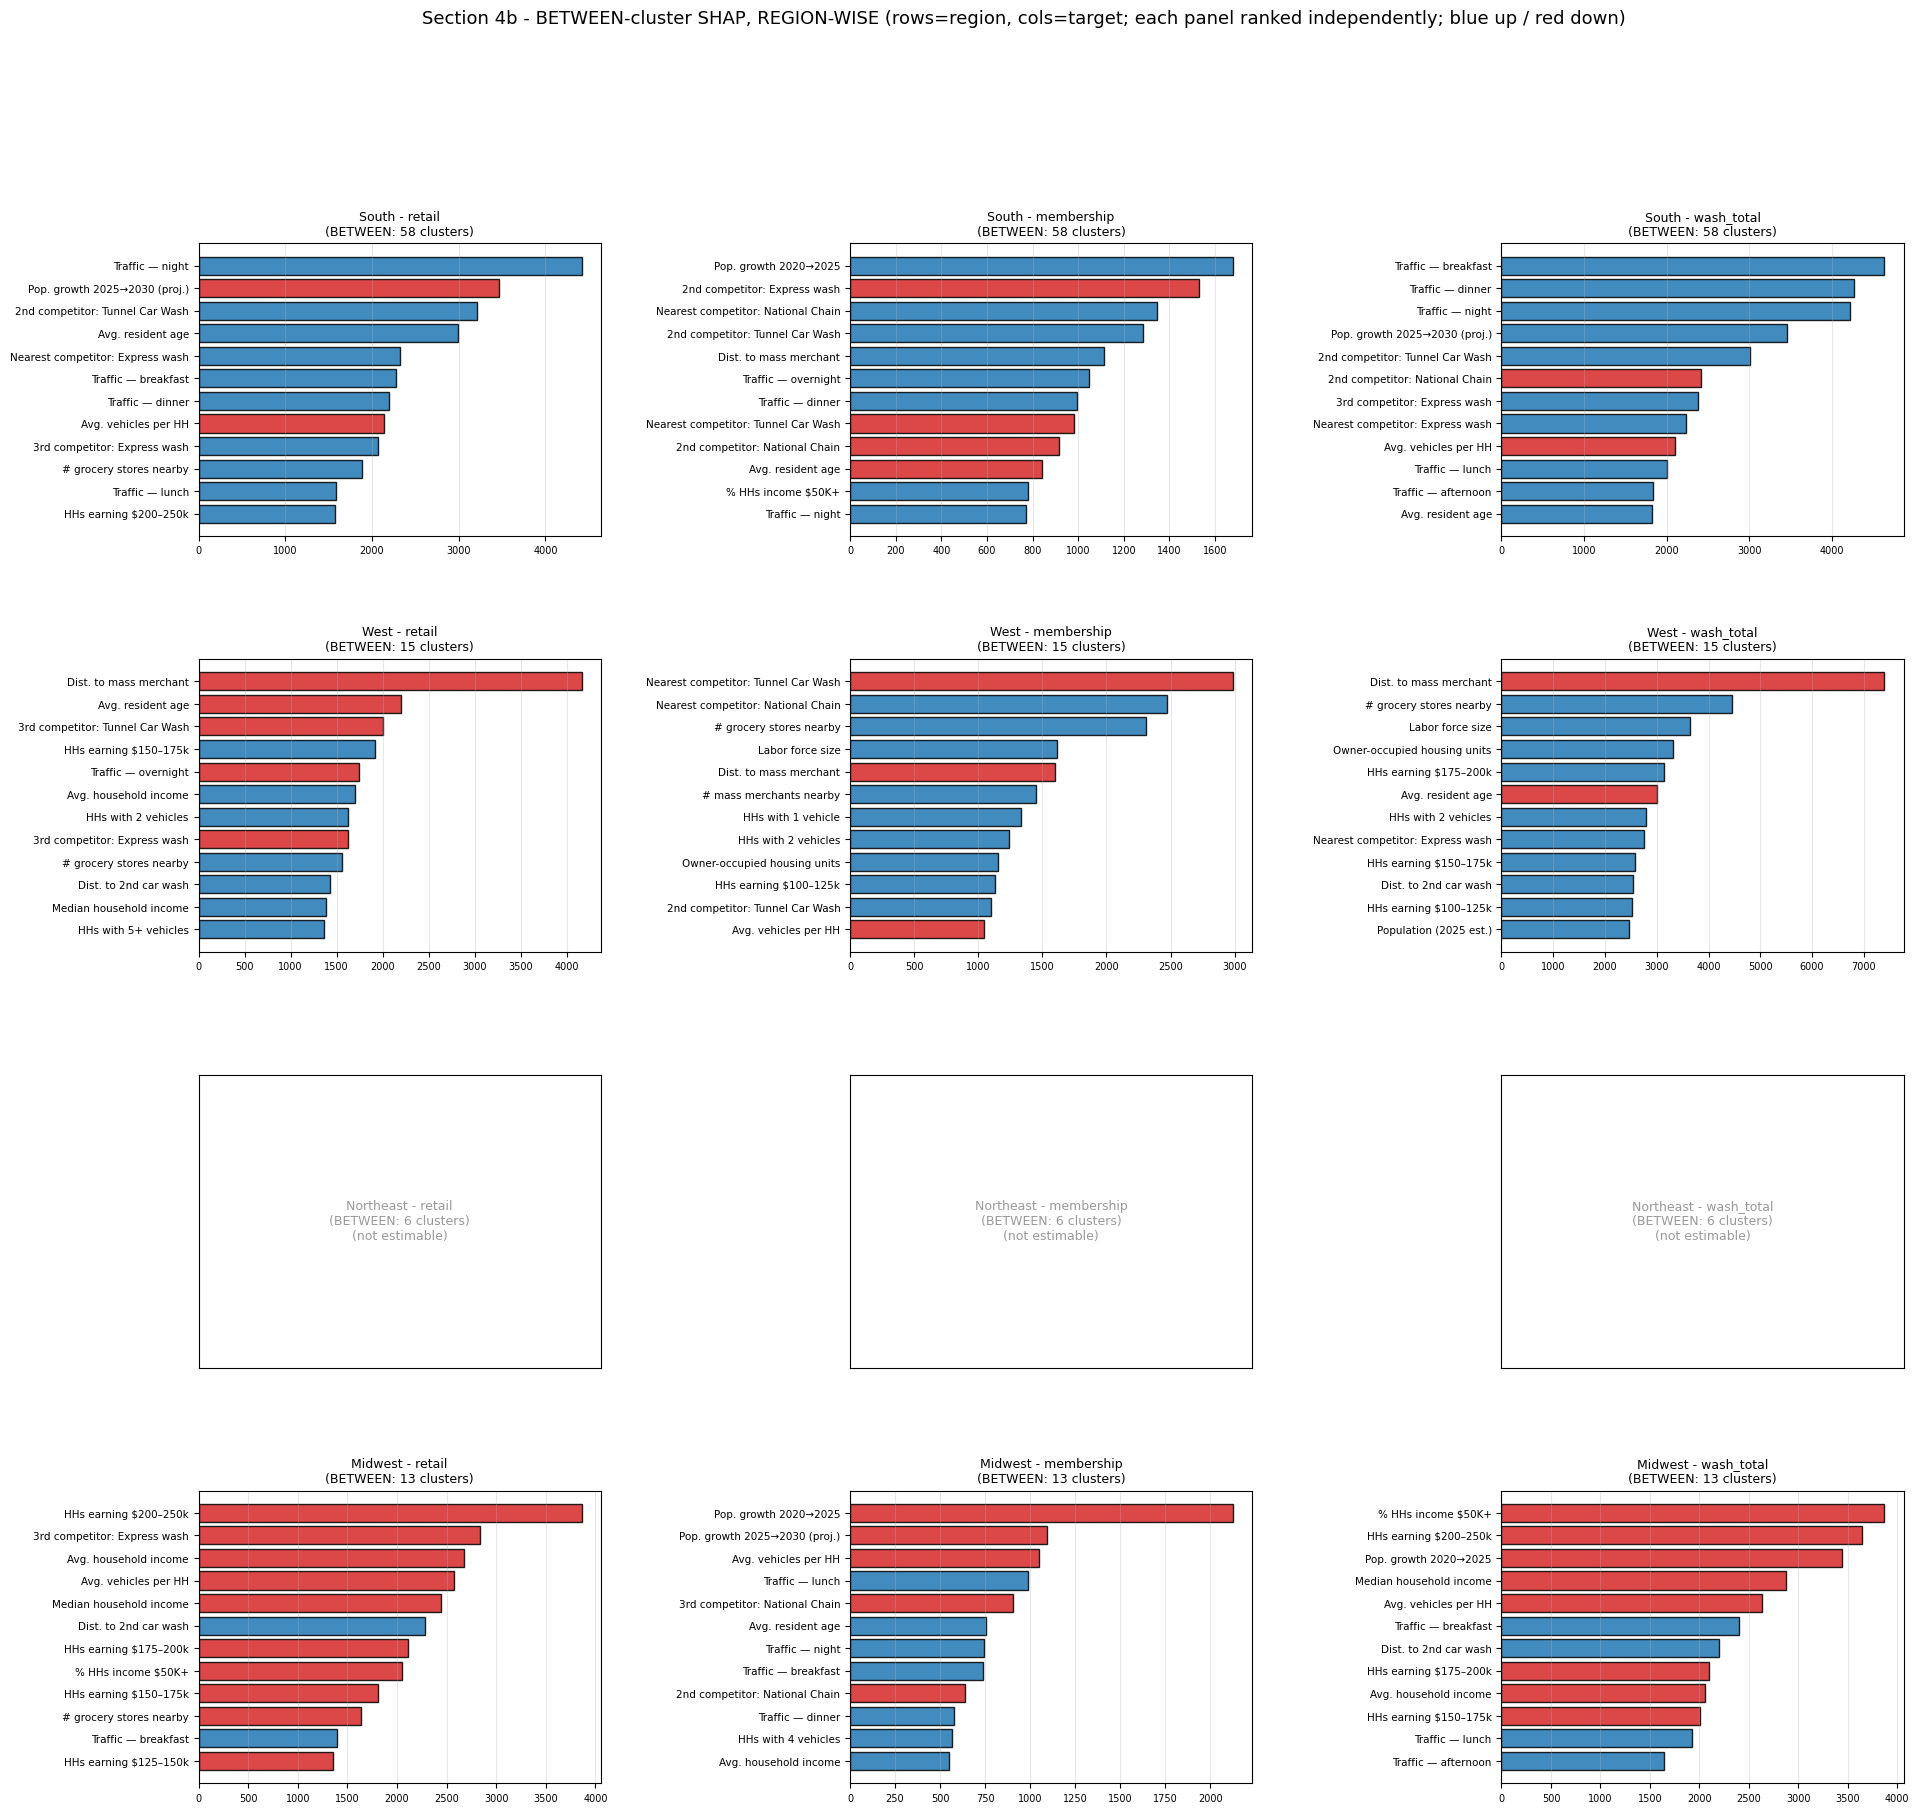

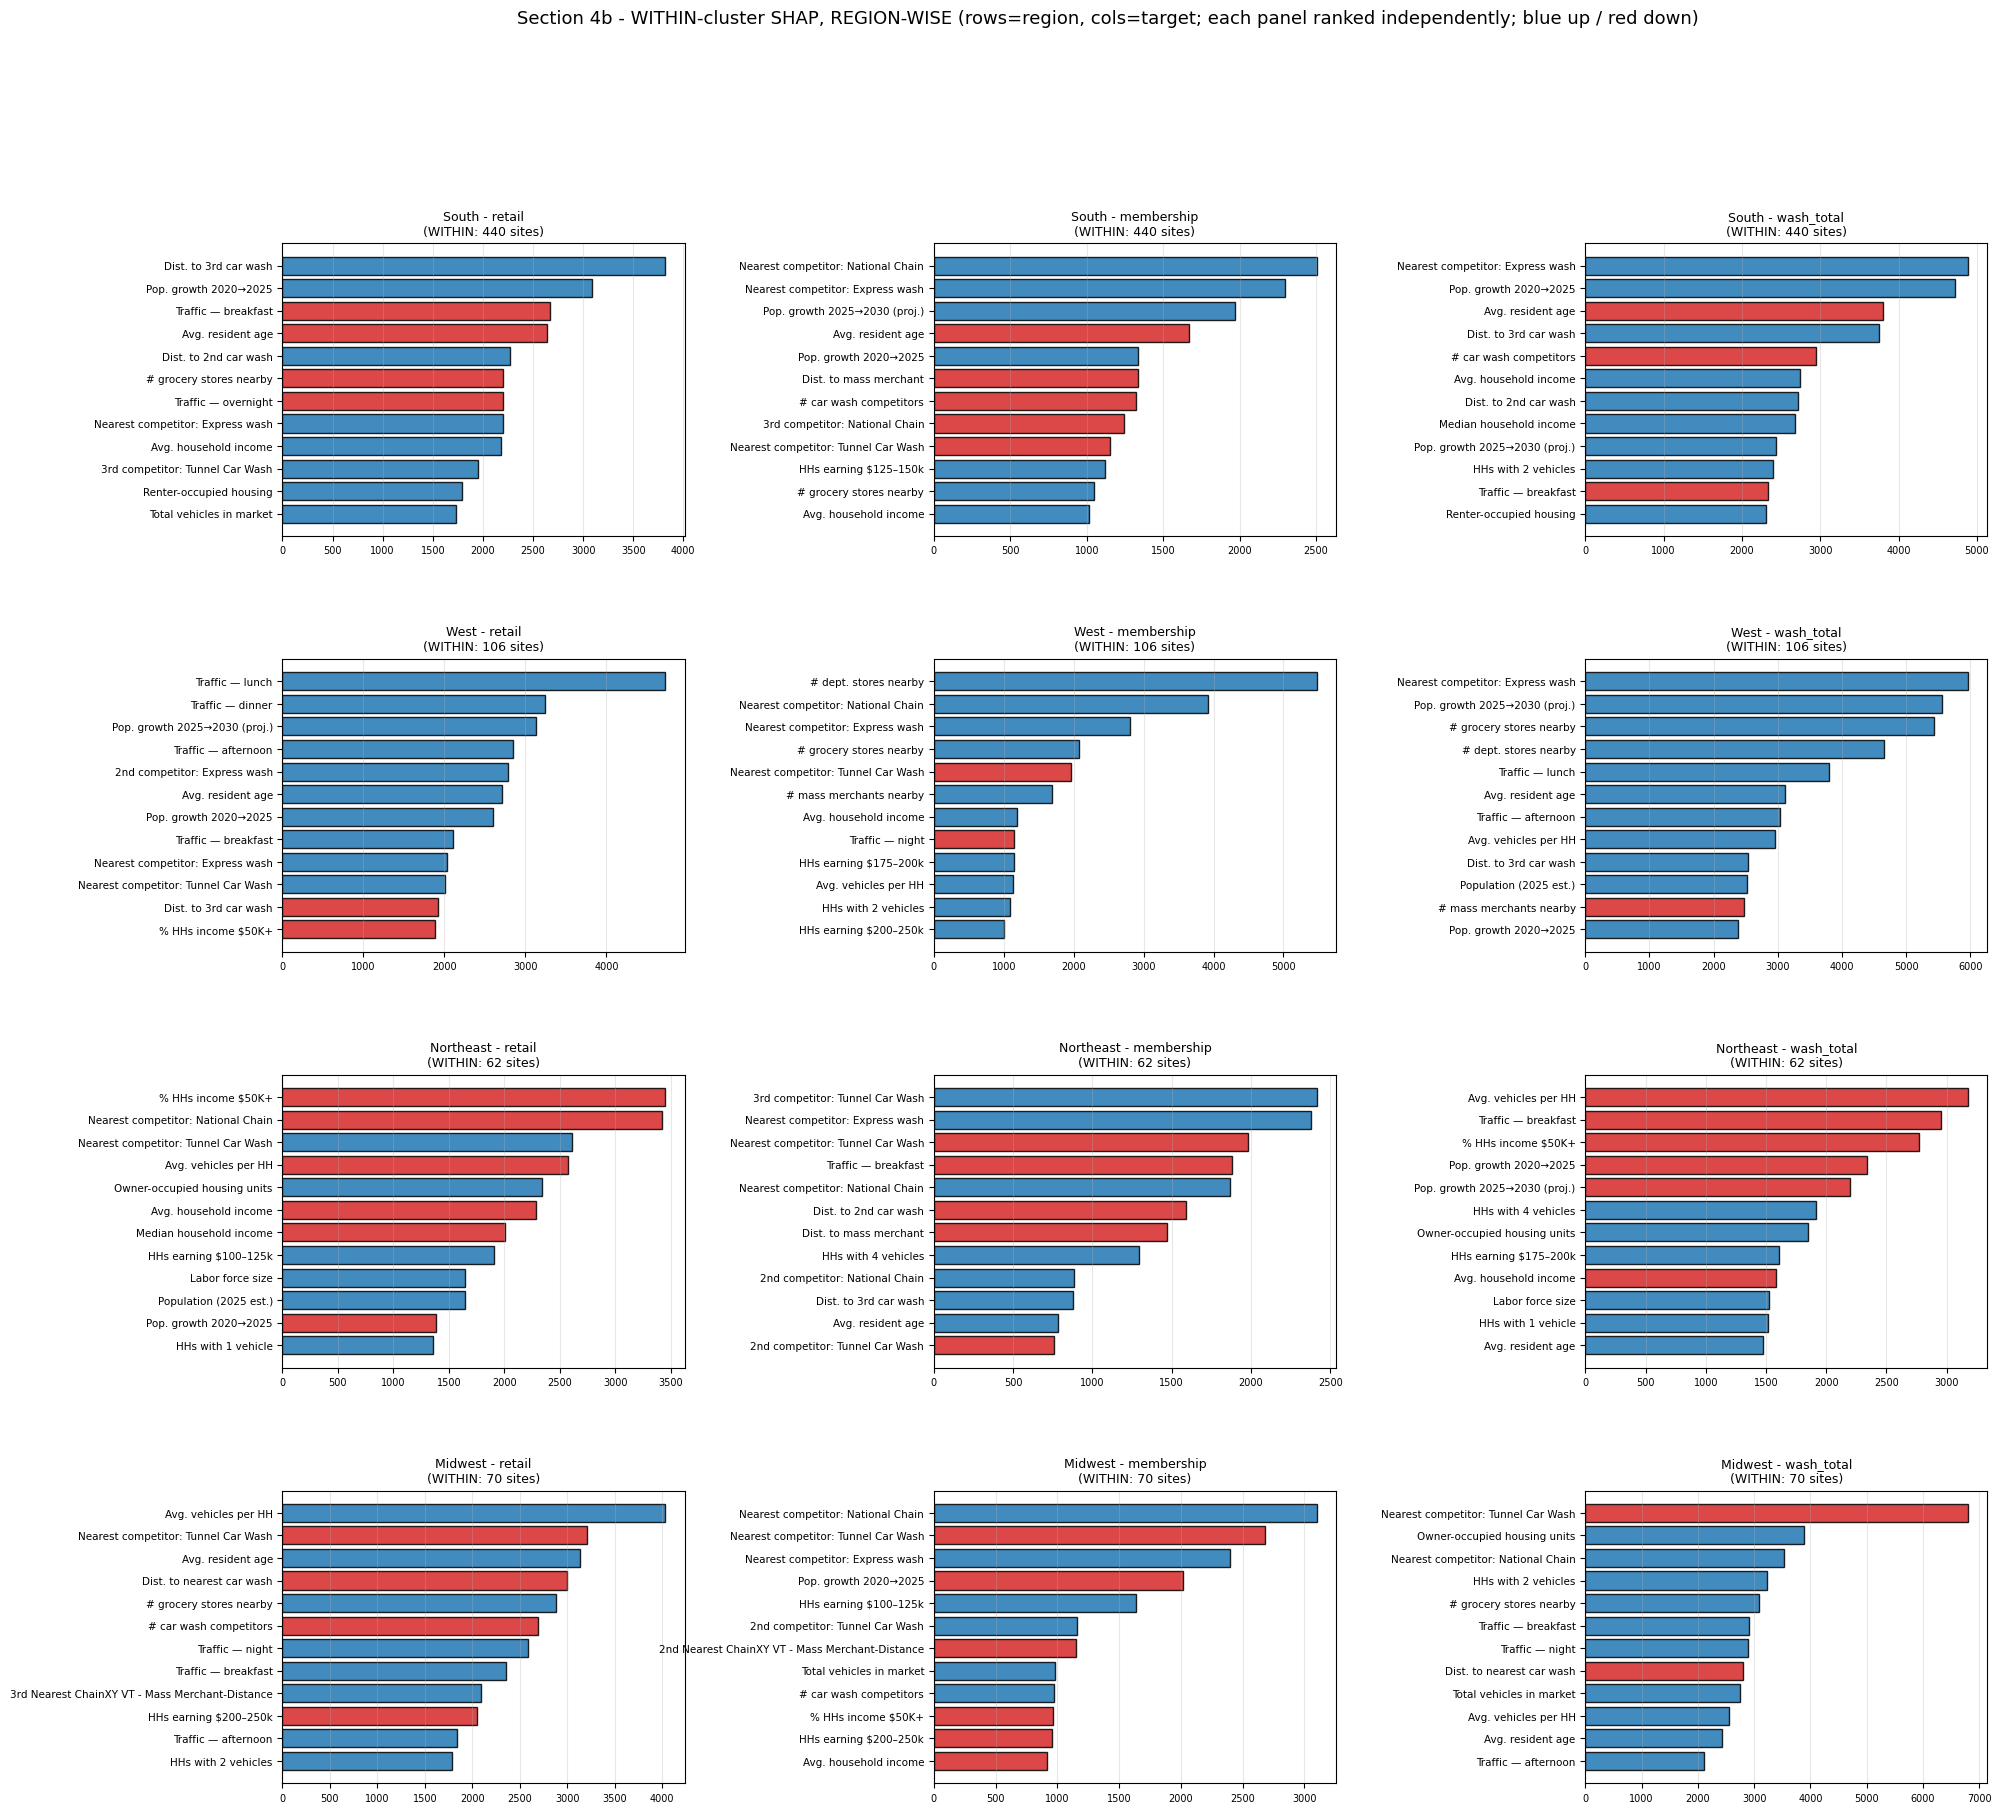

In [8]:
# ============================================================================
# Section 4b — Localisation decomposition, REGION-WISE (between & within, per region)
# ============================================================================
# Section 4's between/within-cluster SHAP, computed separately inside each region.
# Each panel ranked by its OWN top features. Sample sizes stamped on every panel:
# between-cluster needs many clusters (only South qualifies; Northeast blanked),
# within-cluster uses the region's sites. Region splits sit at the noise floor
# (Section 3 negative control) -> trust South, treat the rest as suggestive.
# Reuses fit_shap / feat_label / regions / TARGET_NAMES / X / targets / loc_col / df.

MIN_CLUSTER_RW = 3     # a cluster needs >=3 sites to contribute a stable mean
MIN_CLUST_FIT  = 10    # need >=10 clusters in a region to attempt a between-cluster fit
TOP_N_RW       = 12

vc_rw = loc_col.value_counts()
cluster_region = df.groupby('localisation')['region'].agg(lambda s: s.mode().iloc[0])
region_clusters_rw = {r: [k for k in vc_rw.index if vc_rw[k] >= MIN_CLUSTER_RW and cluster_region[k] == r]
                      for r in regions}

def _rw_panel(ax, imp, sign, title):
    if imp is None:
        ax.text(0.5, 0.5, title + '\n(not estimable)', ha='center', va='center', fontsize=9, color='#999999')
        ax.set_xticks([]); ax.set_yticks([]); return
    order = imp.sort_values(ascending=False).head(TOP_N_RW).index[::-1].tolist()
    cols = ['#1f77b4' if s > 0 else '#d62728' if s < 0 else '#999999' for s in sign.loc[order].values]
    ax.barh(range(len(order)), imp.loc[order].values, color=cols, alpha=0.85, edgecolor='black')
    ax.set_yticks(range(len(order))); ax.set_yticklabels([feat_label(f) for f in order], fontsize=7.5)
    ax.set_title(title, fontsize=9); ax.grid(axis='x', alpha=0.3); ax.tick_params(axis='x', labelsize=7)

for level in ['BETWEEN', 'WITHIN']:
    fig = plt.figure(figsize=(22, 20))
    gs = fig.add_gridspec(len(regions), len(TARGET_NAMES), wspace=0.62, hspace=0.42)
    for ri, r in enumerate(regions):
        cks = region_clusters_rw[r]
        sel = loc_col.isin(cks).values
        for ci, name in enumerate(TARGET_NAMES):
            ax = fig.add_subplot(gs[ri, ci]); y = targets[name]
            if level == 'BETWEEN':
                if len(cks) < MIN_CLUST_FIT:
                    _rw_panel(ax, None, None, f'{r} - {name}\n(BETWEEN: {len(cks)} clusters)'); continue
                Xc = X[sel].groupby(loc_col[sel]).mean()
                yc = y[sel].groupby(loc_col[sel]).mean()
                imp, sign = fit_shap(Xc.reset_index(drop=True), yc.reset_index(drop=True))
                _rw_panel(ax, imp, sign, f'{r} - {name}\n(BETWEEN: {len(cks)} clusters)')
            else:
                g = loc_col[sel]
                keep = (g.map(g.value_counts()) >= 2).values   # need >=2 sites/cluster for within-variation
                Xr = X[sel][keep].copy(); yr = y[sel][keep].copy(); gg = g[keep]
                Xw = Xr - Xr.groupby(gg).transform('mean')
                yw = yr - yr.groupby(gg).transform('mean')
                imp, sign = fit_shap(Xw.reset_index(drop=True), yw.reset_index(drop=True))
                _rw_panel(ax, imp, sign, f'{r} - {name}\n(WITHIN: {int(keep.sum())} sites)')
    fig.suptitle(f'Section 4b - {level}-cluster SHAP, REGION-WISE '
                 f'(rows=region, cols=target; each panel ranked independently; blue up / red down)',
                 fontsize=13, y=0.997)
    plt.show()